## OpenCV Coordinate System
  - X-axis points to the right.
  - Y-axis points down.
  - Z-axis points forward (out of the camera).

<img src="images/opencv_coordinate.png" heigh="333" width="466" />

<br/>
<br/>


## OpenGL Coordinate System
  - X-axis points to the right (East).
  - Y-axis points up.
  - Z-axis (North): Points backward (into the screen) when facing North.

<img src="images/opengl_coordinate.png" heigh="333" width="466" />

<br/>
<br/>



## VTK Coordinate System
  - X-axis points towards East (or right in the typical 3D view).
  - Y-axis points towards North (or up).
  - Z-axis points upwards (out of the screen in a typical 3D setup).

<img src="images/vtk.png"  />

<br/>
<br/>




## For Airplanes/ Drones (PX4 NED (North-East-Down) Coordinates)
   
     - X-axis points towards North.
     - Y-axis points towards East.
     - Z-axis points downwards.

<img src="images/frame_heading.px4.png" width="90%" height="90%"  />


Refs: [1](https://docs.px4.io/main/en/config/flight_controller_orientation.html) 
<br/>
<br/>

<img src="images/RPY_angles_of_airplanes.png"  />

<br/>
<br/>

## For Cars



<img src="images/RPY_angles_of_cars.png"  />


<br/>
<br/>




## Representing Robot Pose


<img src="images/representing_robot_pose1.png" width="50%" height="50%" />

Refs: [1](https://web.archive.org/web/20161029231029/https://paulfurgale.info/news/2014/6/9/representing-robot-pose-the-good-the-bad-and-the-ugly)

<br/>
<br/>

## Transform data from PX4 Autopilot coordinates to VTK


- PX4 Autopilot uses a right-handed coordinate system.
- VTK uses Right-Anterior-Superior (RAS) frame.



**Understand the Coordinate Systems:**
   - **PX4 NED (North-East-Down) Coordinates:**
     - X-axis points towards North.
     - Y-axis points towards East.
     - Z-axis points downwards.
   - **VTK Cartesian Coordinates:**
     - X-axis points towards East (same as PX4 Y-axis).
     - Y-axis points towards North (same as PX4 X-axis).
     - Z-axis points upwards (opposite of PX4 Z-axis).

**Conversion Formula:**
   To convert a point $ P(x_{\text{PX4}}, y_{\text{PX4}}, z_{\text{PX4}}) $ from PX4 coordinates to VTK coordinates $ P(x_{\text{VTK}}, y_{\text{VTK}}, z_{\text{VTK}}) $, you can use the following transformations:
   - $ x_{\text{VTK}} = y_{\text{PX4}} $
   - $ y_{\text{VTK}} = x_{\text{PX4}} $
   - $ z_{\text{VTK}} = -z_{\text{PX4}} $


To transform a point from PX4 Autopilot coordinates $[x, y, z]$ to VTK coordinates, we need to align these axes properly. Based on the conventions:

- **PX4 X-axis** (forward) should map to the **VTK Z-axis** (out of the screen for forward in most visualization contexts).
- **PX4 Y-axis** (right) should map to the **VTK X-axis** (right).
- **PX4 Z-axis** (down) should be inverted to match the **VTK Y-axis** (up).

The transformation matrix to accomplish this in a 3x3 format is:

$
\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & -1 \\
1 & 0 & 0
\end{bmatrix}
$

This matrix translates the axes as follows:

- $x_{vtk} = y_{px4}$ (PX4 Y-axis becomes VTK X-axis)
- $y_{vtk} = -z_{px4}$ (PX4 Z-axis is inverted to become VTK Y-axis)
- $z_{vtk} = x_{px4}$ (PX4 X-axis becomes VTK Z-axis)

Therefore, if you have a point $[x, y, z]$ in PX4 Autopilot coordinates, it would be transformed to $[y, -z, x]$ in VTK coordinates. This transformation properly aligns the coordinate systems between PX4's flight-oriented frame and VTK's visualization-oriented frame.


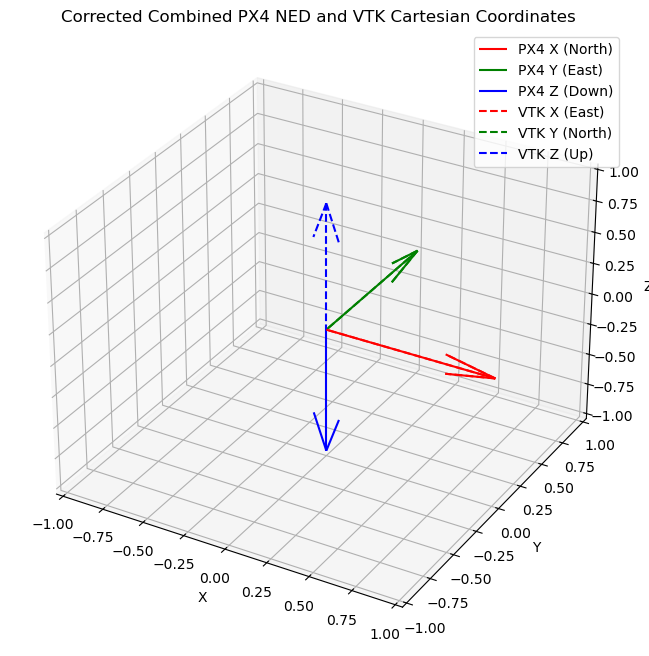

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Setting the axes properties
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Plotting PX4 NED Coordinates
ax.quiver(0, 0, 0, 1, 0, 0, color='r', label='PX4 X (North)')
ax.quiver(0, 0, 0, 0, 1, 0, color='g', label='PX4 Y (East)')
ax.quiver(0, 0, 0, 0, 0, -1, color='b', label='PX4 Z (Down)')

# Plotting VTK Cartesian Coordinates correctly
ax.quiver(0, 0, 0, 1, 0, 0, color='r', linestyle='dashed', label='VTK X (East)')
ax.quiver(0, 0, 0, 0, 1, 0, color='g', linestyle='dashed', label='VTK Y (North)')
ax.quiver(0, 0, 0, 0, 0, 1, color='b', linestyle='dashed', label='VTK Z (Up)')

ax.legend()
ax.set_title('Corrected Combined PX4 NED and VTK Cartesian Coordinates')

plt.show()



## Transform data from OpenCV coordinates to VTK

To transform data from OpenCV coordinates to VTK coordinates and visualize this transformation, we need to understand the typical configurations of these coordinate systems:

- **OpenCV Coordinate System:**
  - X-axis points to the right.
  - Y-axis points down.
  - Z-axis points forward (out of the camera).

- **VTK Coordinate System:**
  - X-axis points towards East (or right in the typical 3D view).
  - Y-axis points towards North (or up).
  - Z-axis points upwards (out of the screen in a typical 3D setup).

To visualize this transformation:
- OpenCV X becomes VTK X.
- OpenCV Y becomes negative VTK Z.
- OpenCV Z becomes VTK Y.

$
\begin{bmatrix}
1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{bmatrix}
$

Here's how this matrix works:

- **X-axis** remains unchanged: $x_{vtk} = x_{opencv}$.
- **Y-axis** is inverted: $y_{vtk} = -y_{opencv}$.
- **Z-axis** is also inverted (to maintain right-handedness with the new Y-axis orientation): $z_{vtk} = -z_{opencv}$.

Thus, if you have a point $[a, b, c]$ in OpenCV, the corresponding point in VTK would be $[a, -b, -c]$. This matrix only handles the transformation of the coordinates. If you also need to translate (move the origin), you might need to use a 4x4 transformation matrix, which can incorporate translation vectors as well.


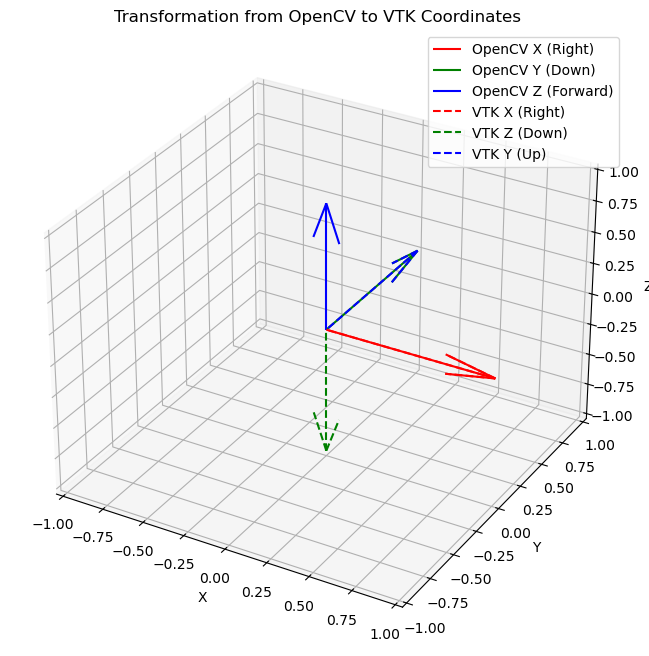

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np



fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Setting the axes properties
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Plotting OpenCV Coordinates
ax.quiver(0, 0, 0, 1, 0, 0, color='r', label='OpenCV X (Right)')
ax.quiver(0, 0, 0, 0, 1, 0, color='g', label='OpenCV Y (Down)')
ax.quiver(0, 0, 0, 0, 0, 1, color='b', label='OpenCV Z (Forward)')

# Transforming and Plotting as VTK Coordinates
ax.quiver(0, 0, 0, 1, 0, 0, color='r', linestyle='dashed', label='VTK X (Right)')
ax.quiver(0, 0, 0, 0, 0, -1, color='g', linestyle='dashed', label='VTK Z (Down)')
ax.quiver(0, 0, 0, 0, 1, 0, color='b', linestyle='dashed', label='VTK Y (Up)')

ax.legend()
ax.set_title('Transformation from OpenCV to VTK Coordinates')

plt.show()


## Transform data from OpenCV coordinates to OpenGL coordinates

To transform data from OpenCV coordinates to OpenGL coordinates, we need to consider the differences between these two coordinate systems:

- **OpenCV Coordinate System:**
  - X-axis points to the right.
  - Y-axis points down.
  - Z-axis points forward (out of the camera).

- **OpenGL Coordinate System:**
  - X-axis points to the right.
  - Y-axis points up.
  - Z-axis points backward (into the screen).

Given these differences, here's how you would transform between OpenCV to OpenGL:
- X-axis remains the same.
- Y-axis in OpenGL is the negative of the Y-axis in OpenCV.
- Z-axis in OpenGL is the negative of the Z-axis in OpenCV.





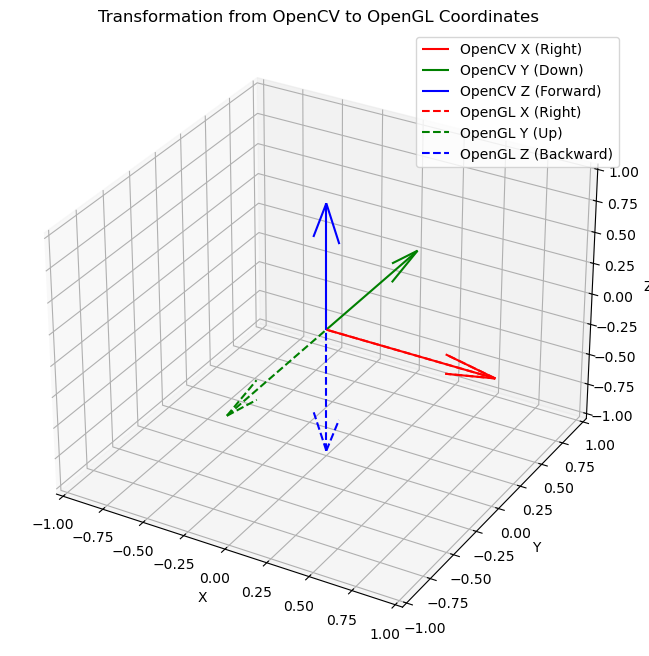

In [5]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Setting the axes properties
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Plotting OpenCV Coordinates with standardized colors
ax.quiver(0, 0, 0, 1, 0, 0, color='r', label='OpenCV X (Right)')
ax.quiver(0, 0, 0, 0, 1, 0, color='g', label='OpenCV Y (Down)')
ax.quiver(0, 0, 0, 0, 0, 1, color='b', label='OpenCV Z (Forward)')

# Transforming and Plotting as OpenGL Coordinates with standardized colors
ax.quiver(0, 0, 0, 1, 0, 0, color='r', linestyle='dashed', label='OpenGL X (Right)')
ax.quiver(0, 0, 0, 0, -1, 0, color='g', linestyle='dashed', label='OpenGL Y (Up)')
ax.quiver(0, 0, 0, 0, 0, -1, color='b', linestyle='dashed', label='OpenGL Z (Backward)')

ax.legend()
ax.set_title('Transformation from OpenCV to OpenGL Coordinates')

plt.show()
